In [1]:
import gdown
import zipfile
import os

# Google Drive file ID from the link
file_id = '1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'dataset.zip'

# Download the file
gdown.download(url, output, quiet=False)

# Extract the zip file
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall('dataset_content')

print("Extraction complete.")

Downloading...
From (original): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ
From (redirected): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ&confirm=t&uuid=1bbe3f13-5519-4de7-b83f-0f9e7730914f
To: /kaggle/working/dataset.zip
100%|██████████| 1.13G/1.13G [00:29<00:00, 37.8MB/s]


Extraction complete.


In [2]:
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 64.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 51.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 97.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Compute capability: {torch.cuda.get_device_capability(0)}")

PyTorch version: 2.7.1+cu118
CUDA available: True
CUDA version: 11.8
GPU: Tesla P100-PCIE-16GB
Compute capability: (6, 0)


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as F
import torchvision.transforms as T

import torchvision.models as models
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
class LensDataset(Dataset):
    def __init__(self, root_dir,transform=None):
        self.data = []
        self.labels = []

        self.classes = ['no', 'sphere', 'vort']
        self.transform = transform

        for label, cls in enumerate(self.classes):
            path = os.path.join(root_dir, cls)

            for file in os.listdir(path):
                if file.endswith(".npy"):
                    self.data.append(os.path.join(path, file))
                    self.labels.append(label)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = np.load(self.data[idx])

        img = torch.tensor(img, dtype=torch.float32)

        # Ensure shape (1, H, W)
        if len(img.shape) == 2:
            img = img.unsqueeze(0)


        # ---> THE NEW RESIZE LINE <---
        img = F.resize(img, [224, 224], antialias=True)
        #print("Converting the 150*150 to 300*300 was Successfully ! ")

        # Convert to 3 channels
        img = img.repeat(3, 1, 1)

        if self.transform:
            img = self.transform(img)

        # 7. Get label (Ensuring it is a long integer, which PyTorch loss functions require)
        label = torch.tensor(self.labels[idx], dtype=torch.long)

        return img, label

In [6]:
# --- Define your Augmentation Pipelines ---

# 1. Training Pipeline: Physics-safe random rotations/flips + ImageNet Normalization
train_transforms = T.Compose([
    T.Resize((224, 224)),  
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=(0, 360)), # Lenses can be at any angle in space
    #T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])


train_dir = "/kaggle/working/dataset_content/dataset/train/"

# Create the Datasets, passing in the specific transform rules for each
train_dataset = LensDataset(root_dir=train_dir, transform=train_transforms)
val_dataset = LensDataset("/kaggle/working/dataset_content/dataset/val")

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

Train size: 30000
Val size: 7500


In [7]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

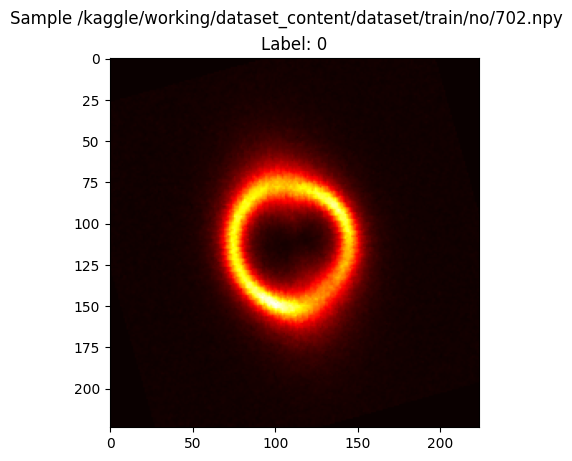

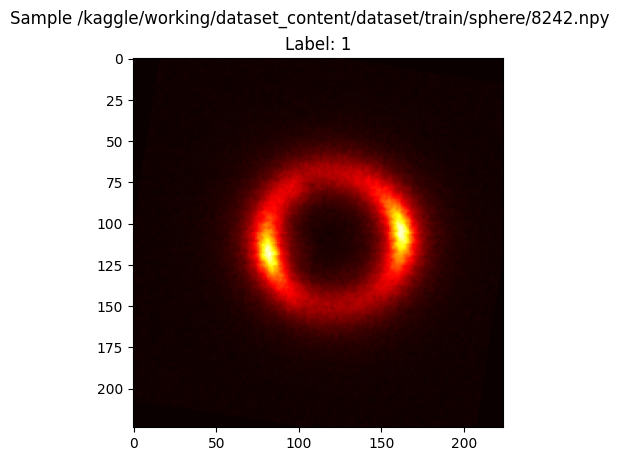

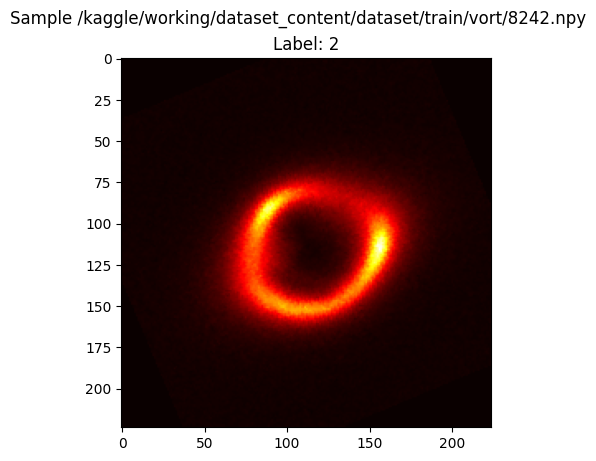

In [8]:
mape=[989,19000,29000]
for i in mape:
    img, label = train_dataset[i]
    plt.imshow(img[0], cmap="hot")
    plt.title(f"Label: {label}")
    plt.suptitle(f"Sample {train_dataset.data[i]}")
    plt.show()

In [9]:
# 1. Load the ConvNeXt-Base model
model = models.convnext_base(weights='DEFAULT')

# 2. Modify the classifier (ConvNeXt calls this the 'classifier' but it contains a '3' index)
# Note: ConvNeXt-Base has 1024 input features in its final layer
num_ftrs = model.classifier[2].in_features 

model.classifier[2] = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(num_ftrs, 3)
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:01<00:00, 241MB/s]


In [10]:

# Keep your current Loss, Optimizer, and Scheduler—they are perfect for this!
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
from torch.optim.lr_scheduler import CosineAnnealingLR
scheduler = CosineAnnealingLR(optimizer, T_max=20)

In [11]:
def train_model(model, train_loader, val_loader, epochs=20):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        scheduler.step()                       # update learning rate after each epoch

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return train_losses, val_losses

In [12]:
train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=20)

Epoch 1/20 | Train Loss: 0.8292 | Val Loss: 0.5195
Epoch 2/20 | Train Loss: 0.5105 | Val Loss: 0.4783
Epoch 3/20 | Train Loss: 0.4704 | Val Loss: 0.4211
Epoch 4/20 | Train Loss: 0.4420 | Val Loss: 0.4155
Epoch 5/20 | Train Loss: 0.4329 | Val Loss: 0.4017
Epoch 6/20 | Train Loss: 0.4236 | Val Loss: 0.3835
Epoch 7/20 | Train Loss: 0.4107 | Val Loss: 0.4087
Epoch 8/20 | Train Loss: 0.4043 | Val Loss: 0.4043
Epoch 9/20 | Train Loss: 0.3955 | Val Loss: 0.3872
Epoch 10/20 | Train Loss: 0.3871 | Val Loss: 0.3856
Epoch 11/20 | Train Loss: 0.3799 | Val Loss: 0.3740
Epoch 12/20 | Train Loss: 0.3740 | Val Loss: 0.3756
Epoch 13/20 | Train Loss: 0.3680 | Val Loss: 0.3642
Epoch 14/20 | Train Loss: 0.3620 | Val Loss: 0.3584
Epoch 15/20 | Train Loss: 0.3572 | Val Loss: 0.3617
Epoch 16/20 | Train Loss: 0.3531 | Val Loss: 0.3573
Epoch 17/20 | Train Loss: 0.3511 | Val Loss: 0.3534
Epoch 18/20 | Train Loss: 0.3461 | Val Loss: 0.3527
Epoch 19/20 | Train Loss: 0.3453 | Val Loss: 0.3531
Epoch 20/20 | Train L

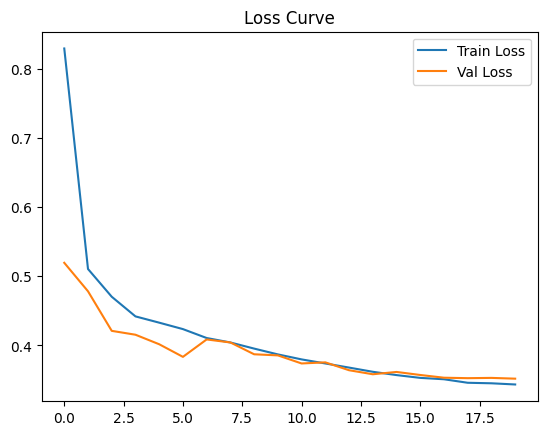

In [13]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

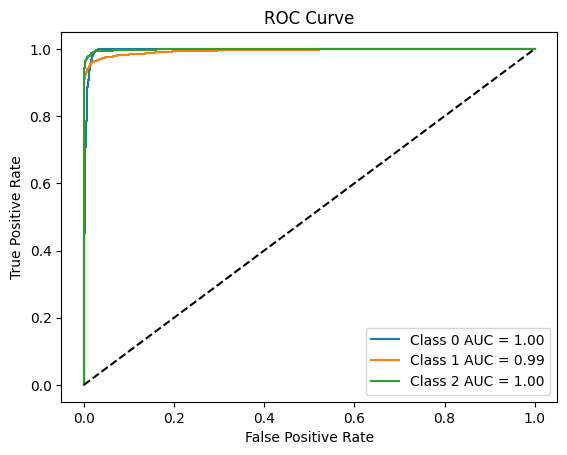

In [14]:
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.vstack(all_probs)
all_labels = np.hstack(all_labels)

# One-hot encode labels
all_labels_bin = label_binarize(all_labels, classes=[0,1,2])

# ROC curve
for i in range(3):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} AUC = {roc_auc:.2f}")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [15]:
torch.save(model.state_dict(), "model.pth")